
***Business Context***

Understanding customer personality and behavior is pivotal for businesses to enhance customer satisfaction and increase revenue. Segmentation based on a customer's personality, demographics, and purchasing behavior allows companies to create tailored marketing campaigns, improve customer retention, and optimize product offerings.

A leading retail company with a rapidly growing customer base seeks to gain deeper insights into their customers' profiles. The company recognizes that understanding customer personalities, lifestyles, and purchasing habits can unlock significant opportunities for personalizing marketing strategies and creating loyalty programs. These insights can help address critical business challenges, such as improving the effectiveness of marketing campaigns, identifying high-value customer groups, and fostering long-term relationships with customers.

With the competition intensifying in the retail space, moving away from generic strategies to more targeted and personalized approaches is essential for sustaining a competitive edge.


***Objective***

In an effort to optimize marketing efficiency and enhance customer experience, the company has embarked on a mission to identify distinct customer segments. By understanding the characteristics, preferences, and behaviors of each group, the company aims to:

Develop personalized marketing campaigns to increase conversion rates.
Create effective retention strategies for high-value customers.
Optimize resource allocation, such as inventory management, pricing strategies, and store layouts.
As a data scientist tasked with this project, your responsibility is to analyze the given customer data, apply machine learning techniques to segment the customer base, and provide actionable insights into the characteristics of each segment.


***Data Dictionary***

The dataset includes historical data on customer demographics, personality traits, and purchasing behaviors. Key attributes are:

Customer Information

ID: Unique identifier for each customer.
Year_Birth: Customer's year of birth.
Education: Education level of the customer.
Marital_Status: Marital status of the customer.
Income: Yearly household income (in dollars).
Kidhome: Number of children in the household.
Teenhome: Number of teenagers in the household.
Dt_Customer: Date when the customer enrolled with the company.
Recency: Number of days since the customer’s last purchase.
Complain: Whether the customer complained in the last 2 years (1 for yes, 0 for no).
Spending Information (Last 2 Years)

MntWines: Amount spent on wine.
MntFruits: Amount spent on fruits.
MntMeatProducts: Amount spent on meat.
MntFishProducts: Amount spent on fish.
MntSweetProducts: Amount spent on sweets.
MntGoldProds: Amount spent on gold products.
Purchase and Campaign Interaction

NumDealsPurchases: Number of purchases made using a discount.
AcceptedCmp1: Response to the 1st campaign (1 for yes, 0 for no).
AcceptedCmp2: Response to the 2nd campaign (1 for yes, 0 for no).
AcceptedCmp3: Response to the 3rd campaign (1 for yes, 0 for no).
AcceptedCmp4: Response to the 4th campaign (1 for yes, 0 for no).
AcceptedCmp5: Response to the 5th campaign (1 for yes, 0 for no).
Response: Response to the last campaign (1 for yes, 0 for no).
Shopping Behavior

NumWebPurchases: Number of purchases made through the company’s website.
NumCatalogPurchases: Number of purchases made using catalogs.
NumStorePurchases: Number of purchases made directly in stores.
NumWebVisitsMonth: Number of visits to the company’s website in the last month.

In [14]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sb

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

In [15]:
#import file from google drive, format if needed with appropriate seperators, and name the dataframe
from google.colab import drive
drive.mount('/content/drive')
cust = pd.read_csv('/content/drive/MyDrive/MIT Course/Customer_Personality_Segmentation.csv', sep='\t')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Cleaning:
Cleaning the data is a crucial part of processing the data and readying it for analysis. Dropping duplicates, filling in null values accordingly, and renaming columns as needed are all important steps of the data cleaning process.


In [16]:
#Understand the dataset shape, columns, and present values
cust.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [17]:
#check data types and scan for mismatched datatypes within the columns (ex:Dt_Customer should be a datetime dtype not object )
cust.dtypes

,0
ID,int64
Year_Birth,int64
Education,object
Marital_Status,object
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,object
Recency,int64
MntWines,int64


In [18]:
cust['Dt_Customer'] = pd.to_datetime(cust['Dt_Customer'], dayfirst=True).dt.date

In [19]:
#scan the df statistical summary
cust.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


***Observation***: The Income column has a high standard deviation of approximately 25k; let's take a deeper look.

In [66]:
#top 7 Income values
cust['Income'].nlargest(7)

,Income
2233,666666.0
617,162397.0
687,160803.0
1300,157733.0
164,157243.0
1653,157146.0
2132,156924.0


In [69]:
#in this instance, where our database is large, we will drop this data point to minimize the deviation of the data points
cust = cust.drop(cust[cust['Income'] == 666666.0].index)
#a second look at the dataframe description
cust.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2239.0,5590.444841,3246.372471,0.0,2827.5,5455.0,8423.5,11191.0
Year_Birth,2239.0,1968.802144,11.985494,1893.0,1959.0,1970.0,1977.0,1996.0
Education,2239.0,2.973649,1.248313,1.0,2.0,2.0,4.0,5.0
Income,2239.0,51963.554712,21410.672116,1730.0,35533.5,51381.5,68277.5,162397.0
Kidhome,2239.0,0.443948,0.538390,0.0,0.0,0.0,1.0,2.0
Teenhome,2239.0,0.506476,0.544555,0.0,0.0,0.0,1.0,2.0
Recency,2239.0,49.121036,28.963662,0.0,24.0,49.0,74.0,99.0
MntWines,2239.0,304.067441,336.614830,0.0,24.0,174.0,504.5,1493.0
MntFruits,2239.0,26.307727,39.781468,0.0,1.0,8.0,33.0,199.0
MntMeatProducts,2239.0,167.016525,225.743829,0.0,16.0,67.0,232.0,1725.0


In [20]:
#scan the dataset for null values and replace/fill/drop if necessary
cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [21]:
rows_with_nulls = cust[cust.isnull().any(axis=1)]
print(rows_with_nulls)

         ID  Year_Birth   Education Marital_Status  Income  Kidhome  Teenhome  \
10     1994        1983  Graduation        Married     NaN        1         0   
27     5255        1986  Graduation         Single     NaN        1         0   
43     7281        1959         PhD         Single     NaN        0         0   
48     7244        1951  Graduation         Single     NaN        2         1   
58     8557        1982  Graduation         Single     NaN        1         0   
71    10629        1973    2n Cycle        Married     NaN        1         0   
90     8996        1957         PhD        Married     NaN        2         1   
91     9235        1957  Graduation         Single     NaN        1         1   
92     5798        1973      Master       Together     NaN        0         0   
128    8268        1961         PhD        Married     NaN        0         1   
133    1295        1963  Graduation        Married     NaN        0         1   
312    2437        1989  Gra

In [22]:
#In this instance, the null values will be replaced with the median value of the Income column
cust['Income'] = cust['Income'].fillna(cust['Income'].median())

In [23]:
#drop columns that won't be used
cust.drop(['Z_CostContact', 'Z_Revenue'], axis=1, inplace=True)

In [24]:
#check for duplicates
duplicates = cust[cust.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [ID, Year_Birth, Education, Marital_Status, Income, Kidhome, Teenhome, Dt_Customer, Recency, MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts, MntGoldProds, NumDealsPurchases, NumWebPurchases, NumCatalogPurchases, NumStorePurchases, NumWebVisitsMonth, AcceptedCmp3, AcceptedCmp4, AcceptedCmp5, AcceptedCmp1, AcceptedCmp2, Complain, Response]
Index: []


In [25]:
#in the marital_status column we have some entries that aren't uniform with the dataset and will be replaced accordingly
filtered_df = cust[cust['Marital_Status'].isin(['Alone', 'Absurd', 'YOLO'])]
print(filtered_df)

         ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
131     433        1958      Master          Alone  61331.0        1   
138    7660        1973         PhD          Alone  35860.0        1   
153      92        1988  Graduation          Alone  34176.0        1   
2093   7734        1993  Graduation         Absurd  79244.0        0   
2134   4369        1957      Master         Absurd  65487.0        0   
2177    492        1973         PhD           YOLO  48432.0        0   
2202  11133        1973         PhD           YOLO  48432.0        0   

      Teenhome Dt_Customer  Recency  MntWines  MntFruits  MntMeatProducts  \
131          1  2013-03-10       42       534          5               47   
138          1  2014-05-19       37        15          0                8   
153          0  2014-05-12       12         5          7               24   
2093         0  2012-12-19       58       471        102              125   
2134         0  2014-01-10       48   

In [26]:
def clean_marital_status(status):
    if status in ['Alone', 'Absurd', 'YOLO']:
        return 'Single'
    else:
        return status
cust['Marital_Status'] = cust['Marital_Status'].apply(clean_marital_status)


print(cust['Marital_Status'].value_counts())

Marital_Status
Married     864
Together    580
Single      487
Divorced    232
Widow        77
Name: count, dtype: int64


In [27]:
#correct spelling mistakes as needed
def education_2nd_cycle(edu):
    if edu.lower() == '2n cycle':
        return '2nd cycle'
    else:
        return edu
cust['Education'] = cust['Education'].apply(education_2nd_cycle)

print(cust['Education'].value_counts())

Education
Graduation    1127
PhD            486
Master         370
2nd cycle      203
Basic           54
Name: count, dtype: int64


## Data Analysis and Visualization:
Using data visualization techniques such as plots and charts presents the data as palatable, eye catching, and easily understood. Plots and charts deepen the analysis of the data and assist companies in making data backed decisions that ultimately can further their companys' success.

Understanding customer profile's, preferance's, and demographic's is key to personalizing marketing campaigns and increasing sales. When the customer base is adequately understood and then analyzed, the success rate of campaigns can be furthered.

**Univariate Analysis**

This histplot can be interchanged with other columns as needed

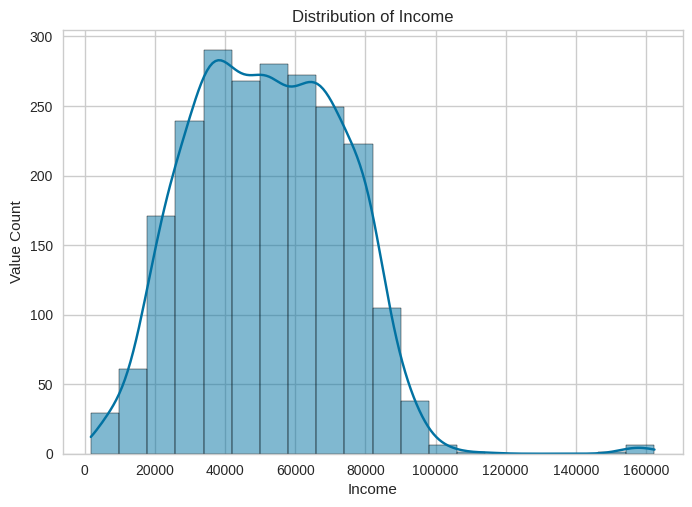

In [70]:
#this plot can be interchanged with column of choice
sb.histplot(data=cust, x='Income', bins=20, kde=True)
plt.ylabel('Value Count')
plt.title('Distribution of Income')
plt.show()

**Bivariate Analysis**

Below are examples of analysis for different values and their relationships


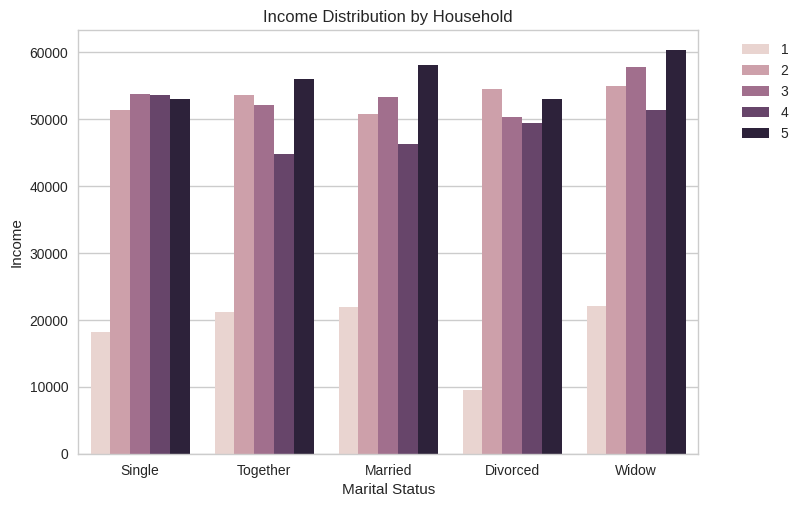

In [71]:
#visualize the distribution of Income per household, divided according to education level
sb.barplot(data=cust, x='Marital_Status', y='Income', hue='Education', ci=None)
plt.xlabel('Marital Status')
plt.ylabel('Income')
plt.title('Income Distribution by Household')
plt.style.use('seaborn-v0_8-whitegrid')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

***Observation***: The more education one has, the higher their income will be

In [30]:
#check average income across the Marital_Status column
avg_income = cust.groupby(['Marital_Status'])['Income'].mean()
def rounded_avg(value):
  return round(value)
rounded_avg_income = avg_income.apply(rounded_avg)
print(rounded_avg_income.sort_values())

Marital_Status
Single      51035
Married     51722
Divorced    52834
Together    53223
Widow       56415
Name: Income, dtype: int64


In [31]:
# What category of goods appeals to each generation? Does it differ across the age groups?

yearly_spending = cust.groupby('Year_Birth')[['MntWines', 'MntFruits', 'MntMeatProducts',
                                              'MntFishProducts', 'MntSweetProducts']].sum()

def best_selling_category_per_year(df):
  """Returns the product category with the highest spending for each year."""
  return df.idxmax(axis=1)

best_sellers = best_selling_category_per_year(yearly_spending)
print(best_sellers)

Year_Birth
1893            MntWines
1899            MntWines
1900            MntWines
1940            MntWines
1941            MntWines
1943            MntWines
1944            MntWines
1945            MntWines
1946            MntWines
1947            MntWines
1948            MntWines
1949            MntWines
1950            MntWines
1951            MntWines
1952            MntWines
1953            MntWines
1954            MntWines
1955            MntWines
1956            MntWines
1957            MntWines
1958            MntWines
1959            MntWines
1960            MntWines
1961            MntWines
1962            MntWines
1963            MntWines
1964            MntWines
1965            MntWines
1966            MntWines
1967            MntWines
1968            MntWines
1969            MntWines
1970            MntWines
1971            MntWines
1972            MntWines
1973            MntWines
1974            MntWines
1975            MntWines
1976            MntWines
1977          

***Observation***: Excluding 1990 and 1992, wine is a fan favorite throughout the years!

## Heatmaps and correlation matrices:
Heatmaps are a powerful tool to display the relationships between different columns and characteristics of the data. In this dataset, a heatmap is helpful for visualizing the positive and negative relationships between income, birth year, products purchased, and campaign success.

In [78]:
#transform the education column to numerical values for analysis
def num_edu (edu):
  if edu == 'Basic':
    return 1
  elif edu == 'Graduation':
    return 2
  elif edu == 'Master':
    return 3
  elif edu == '2nd cycle':
    return 4
  elif edu == 'PhD':
      return 5
cust['Education'] = cust['Education'].apply(num_edu)
print(cust['Education'].value_counts())

Series([], Name: count, dtype: int64)


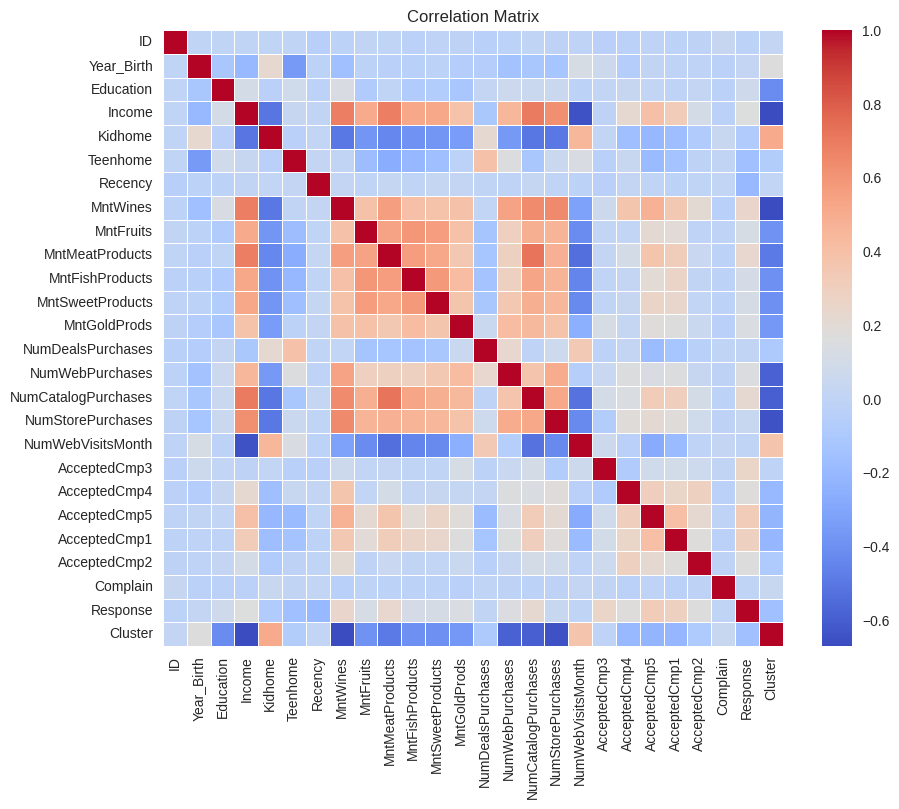

In [72]:
numeric_features_for_corr = cust.select_dtypes(include=[np.number])

correlation_matrix = numeric_features_for_corr.corr()

plt.figure(figsize=(10,8))
sb.heatmap(correlation_matrix, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

***Observation***: The higher one's income, the more goods they purchased either in store, from a catalog, or from the company website.

### Clustering with K Means
When looking at a noisy dataset with multiple intersecting columns and values, clustering the data with k means can be a powerful tool to further the understanding of the data.

In this dataset, categorical and numerical data are present. In order to develop a personalized marketing plan, clustering the data into distinct clusters can point out strong correlations between variables and assist in renewed or continued marketing success.



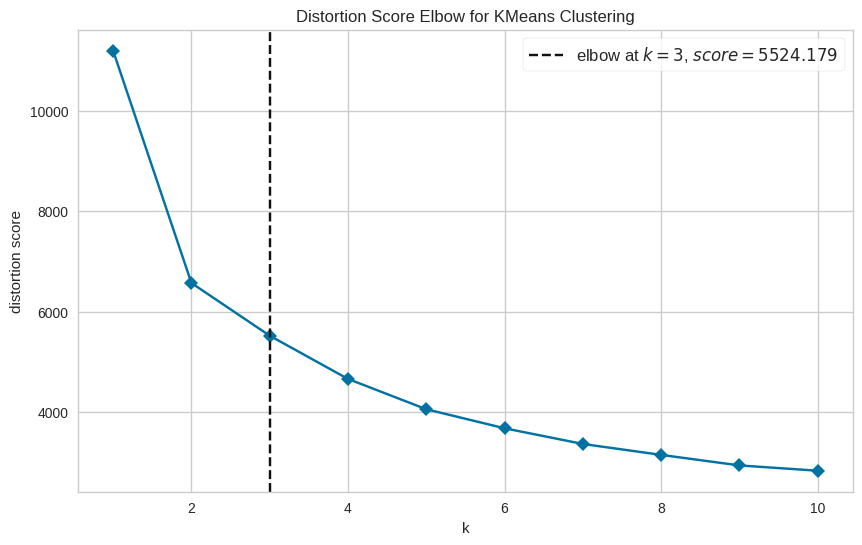

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [73]:
# Select only numeric features for clustering. Exclude columns used for ID and non numeric columns.
features_for_clustering = cust[['Income', 'Education', 'NumStorePurchases', 'NumCatalogPurchases', 'NumWebPurchases']]

# Standardize the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_clustering)

# Convert scaled data back to a DataFrame for better readability
scaled_df = pd.DataFrame(scaled_features, columns=features_for_clustering.columns)

# Employ the K-Means model
kmeans_model = KMeans(random_state=42, n_init=10) # Set n_init to avoid warnings

# Use KElbowVisualizer to find the optimal number of clusters
fig, ax = plt.subplots(figsize=(10, 6))
elbow_visualizer = KElbowVisualizer(kmeans_model, k=(1,11), metric='distortion', timings=False, ax=ax)
elbow_visualizer.fit(scaled_df) # Fit the data to the plot
elbow_visualizer.show() # Finalize and render the visualizer

## Silhouette Score Analysis
In addition to the elbow method, the silhouette score can help determine the optimal number of clusters. When the silhouette score is close to 0, that means the number of clusters (k) needs to be adjusted until the score is closer to 1 which will indicate an optimal k value.


For n_clusters = 2, the average silhouette_score is : 0.38
For n_clusters = 3, the average silhouette_score is : 0.35
For n_clusters = 4, the average silhouette_score is : 0.32
For n_clusters = 5, the average silhouette_score is : 0.32
For n_clusters = 6, the average silhouette_score is : 0.30
For n_clusters = 7, the average silhouette_score is : 0.31
For n_clusters = 8, the average silhouette_score is : 0.31
For n_clusters = 9, the average silhouette_score is : 0.31
For n_clusters = 10, the average silhouette_score is : 0.26


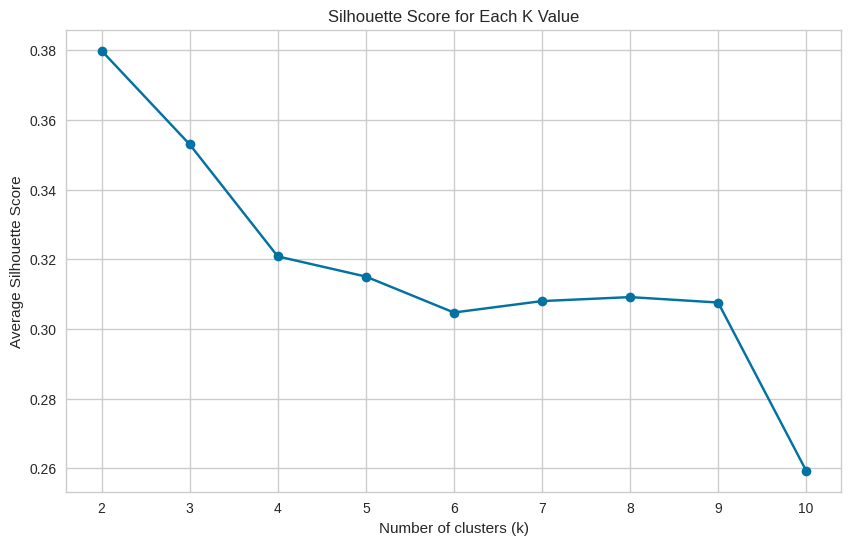

In [74]:
# Evaluate Silhouette Score for different k values
silhouette_scores = []
k_values = range(2, 11) # Silhouette score is defined for k >= 2

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(scaled_df)
    silhouette_avg = silhouette_score(scaled_df, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"For n_clusters = {k}, the average silhouette_score is : {silhouette_avg:.2f}")

# Plotting the Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Score for Each K Value')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.grid(True)
plt.show()



***Observation***: Optimal value of k is 3.

In [75]:
optimal_k = 3 # Based on the elbow method and previous user actions

# Perform K-Means with the optimal number of clusters
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(scaled_df) # Fit and get labels for optimal_k

# Add cluster labels to the original customer DataFrame
cust['Cluster'] = cluster_labels

# Display the count of customers in each cluster
print("Customer counts per cluster:")
print(cust['Cluster'].value_counts())

Customer counts per cluster:
Cluster
0    1067
1     772
2     400
Name: count, dtype: int64


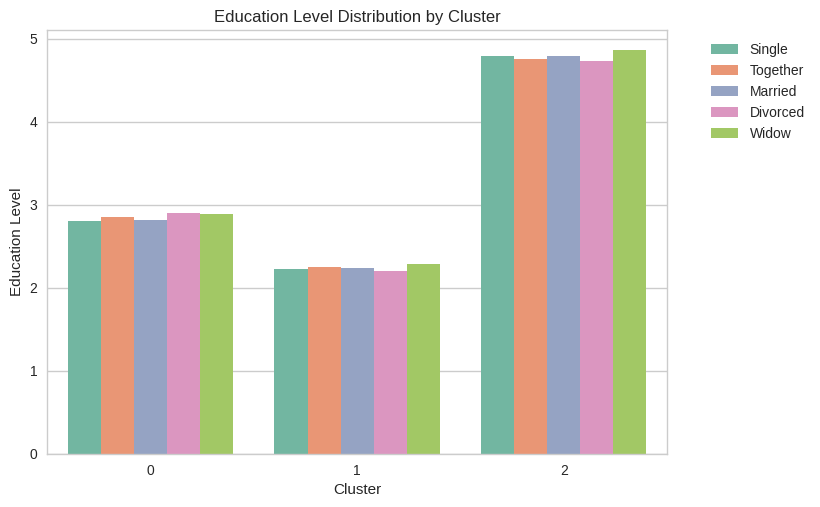

In [76]:
sb.barplot(data=cust, x='Cluster', y='Education', hue='Marital_Status', palette='Set2', ci=None)
plt.ylabel('Education Level')
plt.title('Education Level Distribution by Cluster')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

***Observation***: The Education level is split between the clusters with cluster 2 bearing the most educated population

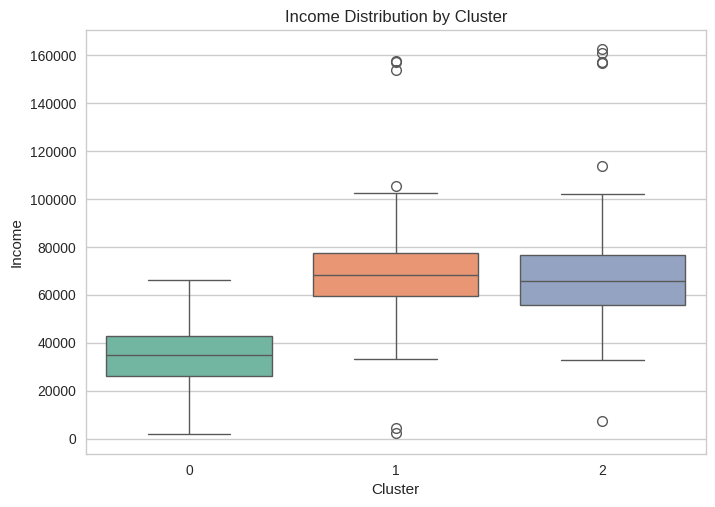

In [77]:
sb.boxplot(data=cust, x='Cluster', y='Income', palette='Set2')
plt.ylabel('Income')
plt.title('Income Distribution by Cluster')
plt.show()

***Observation***: Cluster 2 has the most educated people and as seen above, a higher education is correlated to a higher income and can be seen here in the boxplota. Cluster 2 has customers with a higher income compared to the other clusters.

## Business Recommendations:
As seen above in the barplot, heatmap, and clustering, Education plays a crucial role in ensuring that a customer will have a higher income.
A higher income usually means a customer will frequent a store more and buy more products because they can afford it- this is seen in our dataset as true.
Based off this insight, I would recommend for this business to start marketing in areas where PhD students work, and near college campuses.
During breaks, on the way out of campus, or after a long day at work, it is inevitable that these students will see the campaign and with the right marketing techniques, will be pursuaded to start buying products from this business. As the students graduate, their income will inversely increase- because they are highly educated- and their shopping habits will match their increased income. These students will become the future generation of customers in this database.

Additionally, people love a good glass of wine. This business is doing an excellent job selling tasty wine to eager customers; Wine is the most purchased product for over 5 decades! To optimize this talent, it is only reasonable that the business should advertise their tasty wine collection more. Billboards, video advertisements, and in store wine tastings are all excellent options to take advantage of this business success.